In [4]:
! pip install requests

In [ ]:
df = pd.DataFrame({
    "Title": titles,
    "Author": authors,
    "Price": prices,
    "MRP": mrps,
    "Discount": discounts,
    "Rating": ratings,
    "No_of_Reviews": num_reviews,
    "Category": categories
})

In [66]:
import requests
from bs4 import BeautifulSoup
import numpy as np

title_data, price_data, rating_data, review_data = [], [], [], []
author_data, mrp_data, discount_data, availability_data = [], [], [], []

for i in range(1, 30):   # scrape first 30 pages
    url = f"https://www.flipkart.com/search?q=marvel+comic+book&page={i}"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/114.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)  
    if response.status_code == 403:
        print("403 Forbidden Error!")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    containers = soup.find_all('div', attrs={'class': '_75nlfW'})
    print(f"Page {i} → Found {len(containers)} items")

    for c in containers:
        # Title
        title = c.find('div', attrs={'class': 'slAVV4'})
        title_data.append(title.text if title else np.nan)

        # Price
        price = c.find('div', attrs={'class':'Nx9bqj'})
        price_data.append(price.text if price else np.nan)

        # Reviews
        review = c.find('span', attrs={'class': 'Wphh3N'})
        review_data.append(review.text if review else np.nan)

        # Ratings
        ratings = c.find('div', attrs={'class': 'XQDdHH'})
        rating_data.append(ratings.text if ratings else np.nan)

        # Author
        author = c.find('div', attrs={'class': 'NqpwHC'})
        author_data.append(author.text if author else np.nan)

        # MRP
        mrp = c.find("div", {"class": "yRaY8j"})
        mrp_data.append(mrp.text if mrp else np.nan)

        # Discount
        discount = c.find("div", {"class": "UkUFwK"})
        discount_data.append(discount.text if discount else np.nan)

        # Availability
        availability = c.find("div", {"class": "yiggsN O5Fpg8"})
        availability_data.append(availability.text if availability else np.nan)

print("Total Books Scraped:", len(title_data))


Page 1 → Found 10 items
Page 2 → Found 10 items
Page 3 → Found 10 items
Page 4 → Found 10 items
Page 5 → Found 10 items
Page 6 → Found 10 items
Page 7 → Found 10 items
Page 8 → Found 10 items
Page 9 → Found 0 items
Page 10 → Found 10 items
Page 11 → Found 10 items
Page 12 → Found 10 items
Page 13 → Found 10 items
Page 14 → Found 10 items
Page 15 → Found 10 items
Page 16 → Found 10 items
Page 17 → Found 10 items
Page 18 → Found 10 items
Page 19 → Found 10 items
Page 20 → Found 10 items
Page 21 → Found 10 items
Page 22 → Found 10 items
Page 23 → Found 10 items
Page 24 → Found 10 items
Page 25 → Found 10 items
Page 26 → Found 0 items
Page 27 → Found 0 items
Page 28 → Found 0 items
Page 29 → Found 0 items
Total Books Scraped: 240


In [67]:
import pandas as pd
df = pd.DataFrame({
    "Product Title": title_data,
    "Product Price": price_data,
    "Product Rating": rating_data,
    "Product Review": review_data,
    "Author": author_data,
    "MRP": mrp_data,
    "Discount": discount_data,
    "Availability": availability_data
})

print("Total Books Scraped:", len(df))
print(df.head())

Total Books Scraped: 240
                                       Product Title Product Price  \
0  X-Men: Hellfire GalaEnglish, Paperback, Hickma...          ₹899   
1  World of Reading Avengers Boxed SetEnglish, Pa...        ₹1,178   
2  Trapped by the Green Goblin! (Marvel: Spider-M...          ₹617   
3  Marvel Avengers The Ultimate Character Guide N...          ₹522   
4  Avengers By Jason Aaron Vol. 9English, Paperba...          ₹899   

  Product Rating Product Review                                Author     MRP  \
0            2.3            (3)  English, Paperback, Hickman Jonathan  ₹1,758   
1            NaN            NaN               English, Paperback, DBG  ₹1,316   
2            NaN            NaN     English, Hardcover, Berrios Frank    ₹822   
3            3.9            (8)                English, Hardcover, DK    ₹699   
4              5            (3)       English, Paperback, Aaron Jason  ₹1,949   

  Discount   Availability  
0  48% off  Only few left  
1  10% off 

In [68]:
df.to_csv("marvel.csv", index=False )

In [93]:
df = pd.read_csv('marvel.csv')
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left
...,...,...,...,...,...,...,...,...
235,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,NaN,NaN,"English, Paperback, Aaron Jason","₹1,949",53% off,NaN
236,Star Wars Legends Epic Collection: The Origina...,"₹3,094",NaN,NaN,"English, Paperback, Various Ann","₹4,499",31% off,NaN
237,Avengers Epic Collection: This Beachhead Earth...,"₹2,880",NaN,NaN,"English, Paperback, Thomas Roy","₹5,202",44% off,NaN
238,"Trials Of X Vol. 5English, Paperback, Spurrier...","₹1,298",NaN,NaN,"English, Paperback, Spurrier Si","₹1,625",20% off,NaN


# American Comics

In [94]:
import pandas as pd

# Read your CSV file
df = pd.read_csv("marvel.csv")

# Add new column with default value
df["Company"] = "Marvel"
df.to_csv("Marvel1.csv", index=False)

In [95]:
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left,Marvel
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left,Marvel
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left,Marvel
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left,Marvel
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left,Marvel
...,...,...,...,...,...,...,...,...,...
235,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,NaN,NaN,"English, Paperback, Aaron Jason","₹1,949",53% off,NaN,Marvel
236,Star Wars Legends Epic Collection: The Origina...,"₹3,094",NaN,NaN,"English, Paperback, Various Ann","₹4,499",31% off,NaN,Marvel
237,Avengers Epic Collection: This Beachhead Earth...,"₹2,880",NaN,NaN,"English, Paperback, Thomas Roy","₹5,202",44% off,NaN,Marvel
238,"Trials Of X Vol. 5English, Paperback, Spurrier...","₹1,298",NaN,NaN,"English, Paperback, Spurrier Si","₹1,625",20% off,NaN,Marvel


# Dc Comics

In [70]:
import requests
from bs4 import BeautifulSoup
import numpy as np

title_data, price_data, rating_data, review_data = [], [], [], []
author_data, mrp_data, discount_data, availability_data = [], [], [], []

for i in range(1, 30):   # scrape first 30 pages
    url = f"https://www.flipkart.com/search?q=dc+comics+book&page={i}"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/114.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)  
    if response.status_code == 403:
        print("403 Forbidden Error!")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    containers = soup.find_all('div', attrs={'class': '_75nlfW'})
    print(f"Page {i} → Found {len(containers)} items")

    for c in containers:
        # Title
        title = c.find('div', attrs={'class': 'slAVV4'})
        title_data.append(title.text if title else np.nan)

        # Price
        price = c.find('div', attrs={'class':'Nx9bqj'})
        price_data.append(price.text if price else np.nan)

        # Reviews
        review = c.find('span', attrs={'class': 'Wphh3N'})
        review_data.append(review.text if review else np.nan)

        # Ratings
        ratings = c.find('div', attrs={'class': 'XQDdHH'})
        rating_data.append(ratings.text if ratings else np.nan)

        # Author
        author = c.find('div', attrs={'class': 'NqpwHC'})
        author_data.append(author.text if author else np.nan)

        # MRP
        mrp = c.find("div", {"class": "yRaY8j"})
        mrp_data.append(mrp.text if mrp else np.nan)

        # Discount
        discount = c.find("div", {"class": "UkUFwK"})
        discount_data.append(discount.text if discount else np.nan)

        # Availability
        availability = c.find("div", {"class": "yiggsN O5Fpg8"})
        availability_data.append(availability.text if availability else np.nan)

print("Total Books Scraped:", len(title_data))


Page 1 → Found 10 items
Page 2 → Found 10 items
Page 3 → Found 10 items
Page 4 → Found 10 items
Page 5 → Found 10 items
Page 6 → Found 10 items
Page 7 → Found 10 items
Page 8 → Found 10 items
Page 9 → Found 10 items
Page 10 → Found 10 items
Page 11 → Found 10 items
Page 12 → Found 10 items
Page 13 → Found 10 items
Page 14 → Found 10 items
Page 15 → Found 10 items
Page 16 → Found 10 items
Page 17 → Found 10 items
Page 18 → Found 10 items
Page 19 → Found 10 items
Page 20 → Found 10 items
Page 21 → Found 10 items
Page 22 → Found 10 items
Page 23 → Found 10 items
Page 24 → Found 10 items
Page 25 → Found 10 items
Page 26 → Found 0 items
Page 27 → Found 0 items
Page 28 → Found 0 items
Page 29 → Found 0 items
Total Books Scraped: 250


In [71]:
import pandas as pd
df = pd.DataFrame({
    "Product Title": title_data,
    "Product Price": price_data,
    "Product Rating": rating_data,
    "Product Review": review_data,
    "Author": author_data,
    "MRP": mrp_data,
    "Discount": discount_data,
    "Availability": availability_data
})

print("Total Books Scraped:", len(df))
print(df.head())

Total Books Scraped: 250
                                       Product Title Product Price  \
0  Super Sons Volume 3English, Paperback, Tomasi ...          ₹924   
1  Fourth World by Jack Kirby Omnibus (New Printi...        ₹9,235   
2  DCeased: Dead PlanetEnglish, Paperback, Taylor...        ₹1,359   
3  Space Jam: A New LegacyEnglish, Paperback, Coh...          ₹864   
4  DC Universe by Len WeinEnglish, Hardcover, Wei...        ₹1,816   

  Product Rating Product Review                               Author      MRP  \
0            NaN            NaN  English, Paperback, Tomasi Peter J.     ₹975   
1            NaN            NaN       English, Hardcover, Kirby Jack  ₹11,999   
2            NaN            NaN       English, Paperback, Taylor Tom   ₹1,599   
3            NaN            NaN       English, Paperback, Cohen Ivan   ₹1,099   
4            NaN            NaN         English, Hardcover, Wein Len   ₹2,199   

  Discount Availability  
0   5% off  Only 3 left  
1  23% off  Onl

In [72]:
df.to_csv("dc.csv", index=False )

In [73]:
df=pd.read_csv("dc.csv")
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability
0,"Super Sons Volume 3English, Paperback, Tomasi ...",₹924,NaN,NaN,"English, Paperback, Tomasi Peter J.",₹975,5% off,Only 3 left
1,Fourth World by Jack Kirby Omnibus (New Printi...,"₹9,235",NaN,NaN,"English, Hardcover, Kirby Jack","₹11,999",23% off,Only 2 left
2,"DCeased: Dead PlanetEnglish, Paperback, Taylor...","₹1,359",NaN,NaN,"English, Paperback, Taylor Tom","₹1,599",15% off,Only 3 left
3,"Space Jam: A New LegacyEnglish, Paperback, Coh...",₹864,NaN,NaN,"English, Paperback, Cohen Ivan","₹1,099",21% off,Only 1 left
4,"DC Universe by Len WeinEnglish, Hardcover, Wei...","₹1,816",NaN,NaN,"English, Hardcover, Wein Len","₹2,199",17% off,Only 3 left
...,...,...,...,...,...,...,...,...
245,"The DC Book of PrideEnglish, Hardcover, DK Jad...",₹696,NaN,NaN,"English, Hardcover, DK Jadzia",₹850,18% off,NaN
246,The First Book Of Horace's Satires (1842)Engli...,"₹2,192",NaN,NaN,"English, Paperback, Horace","₹2,307",4% off,NaN
247,The Little Corporal: A Comic Opera in Three Ac...,"₹1,414",NaN,NaN,"English, Hardcover, Smith Harry B.","₹1,415",28% off,NaN
248,DK Super Readers Level 3 DC Supergirl Girl of ...,₹550,NaN,NaN,"English, Paperback, Hallam Frankie",₹775,29% off,NaN


In [74]:
import pandas as pd

# Read your CSV file
df = pd.read_csv("dc.csv")

# Add new column with default value
df["Company"] = "DC"
df.to_csv("DC1.csv", index=False)

In [75]:
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company
0,"Super Sons Volume 3English, Paperback, Tomasi ...",₹924,NaN,NaN,"English, Paperback, Tomasi Peter J.",₹975,5% off,Only 3 left,DC
1,Fourth World by Jack Kirby Omnibus (New Printi...,"₹9,235",NaN,NaN,"English, Hardcover, Kirby Jack","₹11,999",23% off,Only 2 left,DC
2,"DCeased: Dead PlanetEnglish, Paperback, Taylor...","₹1,359",NaN,NaN,"English, Paperback, Taylor Tom","₹1,599",15% off,Only 3 left,DC
3,"Space Jam: A New LegacyEnglish, Paperback, Coh...",₹864,NaN,NaN,"English, Paperback, Cohen Ivan","₹1,099",21% off,Only 1 left,DC
4,"DC Universe by Len WeinEnglish, Hardcover, Wei...","₹1,816",NaN,NaN,"English, Hardcover, Wein Len","₹2,199",17% off,Only 3 left,DC
...,...,...,...,...,...,...,...,...,...
245,"The DC Book of PrideEnglish, Hardcover, DK Jad...",₹696,NaN,NaN,"English, Hardcover, DK Jadzia",₹850,18% off,NaN,DC
246,The First Book Of Horace's Satires (1842)Engli...,"₹2,192",NaN,NaN,"English, Paperback, Horace","₹2,307",4% off,NaN,DC
247,The Little Corporal: A Comic Opera in Three Ac...,"₹1,414",NaN,NaN,"English, Hardcover, Smith Harry B.","₹1,415",28% off,NaN,DC
248,DK Super Readers Level 3 DC Supergirl Girl of ...,₹550,NaN,NaN,"English, Paperback, Hallam Frankie",₹775,29% off,NaN,DC


# Indian Comics

In [77]:
import requests
from bs4 import BeautifulSoup
import numpy as np

title_data, price_data, rating_data, review_data = [], [], [], []
author_data, mrp_data, discount_data, availability_data = [], [], [], []

for i in range(1, 30):   # scrape first 30 pages
    url = f"https://www.flipkart.com/search?q=Amar+Chitra+Katha&page={i}"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/114.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)  
    if response.status_code == 403:
        print("403 Forbidden Error!")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    containers = soup.find_all('div', attrs={'class': '_75nlfW'})
    print(f"Page {i} → Found {len(containers)} items")

    for c in containers:
        # Title
        title = c.find('div', attrs={'class': 'slAVV4'})
        title_data.append(title.text if title else np.nan)

        # Price
        price = c.find('div', attrs={'class':'Nx9bqj'})
        price_data.append(price.text if price else np.nan)

        # Reviews
        review = c.find('span', attrs={'class': 'Wphh3N'})
        review_data.append(review.text if review else np.nan)

        # Ratings
        ratings = c.find('div', attrs={'class': 'XQDdHH'})
        rating_data.append(ratings.text if ratings else np.nan)

        # Author
        author = c.find('div', attrs={'class': 'NqpwHC'})
        author_data.append(author.text if author else np.nan)

        # MRP
        mrp = c.find("div", {"class": "yRaY8j"})
        mrp_data.append(mrp.text if mrp else np.nan)

        # Discount
        discount = c.find("div", {"class": "UkUFwK"})
        discount_data.append(discount.text if discount else np.nan)

        # Availability
        availability = c.find("div", {"class": "yiggsN O5Fpg8"})
        availability_data.append(availability.text if availability else np.nan)

print("Total Books Scraped:", len(title_data))


Page 1 → Found 10 items
Page 2 → Found 10 items
Page 3 → Found 10 items
Page 4 → Found 10 items
Page 5 → Found 10 items
Page 6 → Found 10 items
Page 7 → Found 10 items
Page 8 → Found 10 items
Page 9 → Found 10 items
Page 10 → Found 10 items
Page 11 → Found 10 items
Page 12 → Found 10 items
Page 13 → Found 10 items
Page 14 → Found 10 items
Page 15 → Found 10 items
Page 16 → Found 10 items
Page 17 → Found 10 items
Page 18 → Found 10 items
Page 19 → Found 10 items
Page 20 → Found 10 items
Page 21 → Found 5 items
Page 22 → Found 0 items
Page 23 → Found 0 items
Page 24 → Found 0 items
Page 25 → Found 0 items
Page 26 → Found 0 items
Page 27 → Found 0 items
Page 28 → Found 0 items
Page 29 → Found 0 items
Total Books Scraped: 205


In [78]:
import pandas as pd
df = pd.DataFrame({
    "Product Title": title_data,
    "Product Price": price_data,
    "Product Rating": rating_data,
    "Product Review": review_data,
    "Author": author_data,
    "MRP": mrp_data,
    "Discount": discount_data,
    "Availability": availability_data
})

print("Total Books Scraped:", len(df))
print(df.head())

Total Books Scraped: 205
                                       Product Title Product Price  \
0  Amar Chitra Katha Folktales CollectionEnglish,...          ₹328   
1  PradyumnaEnglish, Paperback, Chandrakant Kamal...          ₹159   
2  TINKLE ORIGINS: VOLUME TWO [Paperback] RAJNI T...          ₹355   
3  Suppandi 7 Fire AwareEnglish, Paperback, Amar ...          ₹170   
4  Shikari Shambu - 1 (Adventure Awaits)English, ...          ₹182   

  Product Rating Product Review  \
0            4.4          (264)   
1              5            (4)   
2            4.7           (59)   
3            4.5          (113)   
4            4.4          (165)   

                                              Author   MRP Discount  \
0   English, Multiple copy pack, Baretto Christopher  ₹499  34% off   
1             English, Paperback, Chandrakant Kamala  ₹199  20% off   
2              English, Hardcover, Amar Chitra Katha  ₹499  28% off   
3  English, Paperback, Amar Chitra Katha Private ...  ₹225 

In [79]:
df.to_csv("ACK.csv", index=False )

In [80]:
df=pd.read_csv("ACK.csv")
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability
0,"Amar Chitra Katha Folktales CollectionEnglish,...",₹328,4.4,(264),"English, Multiple copy pack, Baretto Christopher",₹499,34% off,Only few left
1,"PradyumnaEnglish, Paperback, Chandrakant Kamal...",₹159,5.0,(4),"English, Paperback, Chandrakant Kamala",₹199,20% off,Only few left
2,TINKLE ORIGINS: VOLUME TWO [Paperback] RAJNI T...,₹355,4.7,(59),"English, Hardcover, Amar Chitra Katha",₹499,28% off,Only few left
3,"Suppandi 7 Fire AwareEnglish, Paperback, Amar ...",₹170,4.5,(113),"English, Paperback, Amar Chitra Katha Private ...",₹225,24% off,Only few left
4,"Shikari Shambu - 1 (Adventure Awaits)English, ...",₹182,4.4,(165),"English, Paperback, Fernandes Luis",₹225,19% off,Only few left
...,...,...,...,...,...,...,...,...
200,"More Tales of BirbalEnglish, Paperback, unknow...",₹185,4.4,(31),"English, Paperback, unknown",₹199,7% off,NaN
201,Currently unavailableMarathi Books For Kids 6-...,₹186,4.4,(165),"Paperback, Saket Prakashan",₹236,21% off,Big Billion Days Price
202,Currently unavailableEpic Stories: Special 10 ...,₹849,2.8,(4),"Paperback, Amar Chitra Katha",₹999,15% off,Hot Deal
203,Currently unavailableTinkle Double Digest No.2...,₹116,4.8,(4),"Paperback, Amar Chitra Katha",₹179,35% off,Hot Deal


In [81]:
import pandas as pd

# Read your CSV file
df = pd.read_csv("ACK.csv")

# Add new column with default value
df["Company"] = "ACK"
df.to_csv("ACK1.csv", index=False)

In [82]:
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company
0,"Amar Chitra Katha Folktales CollectionEnglish,...",₹328,4.4,(264),"English, Multiple copy pack, Baretto Christopher",₹499,34% off,Only few left,ACK
1,"PradyumnaEnglish, Paperback, Chandrakant Kamal...",₹159,5.0,(4),"English, Paperback, Chandrakant Kamala",₹199,20% off,Only few left,ACK
2,TINKLE ORIGINS: VOLUME TWO [Paperback] RAJNI T...,₹355,4.7,(59),"English, Hardcover, Amar Chitra Katha",₹499,28% off,Only few left,ACK
3,"Suppandi 7 Fire AwareEnglish, Paperback, Amar ...",₹170,4.5,(113),"English, Paperback, Amar Chitra Katha Private ...",₹225,24% off,Only few left,ACK
4,"Shikari Shambu - 1 (Adventure Awaits)English, ...",₹182,4.4,(165),"English, Paperback, Fernandes Luis",₹225,19% off,Only few left,ACK
...,...,...,...,...,...,...,...,...,...
200,"More Tales of BirbalEnglish, Paperback, unknow...",₹185,4.4,(31),"English, Paperback, unknown",₹199,7% off,NaN,ACK
201,Currently unavailableMarathi Books For Kids 6-...,₹186,4.4,(165),"Paperback, Saket Prakashan",₹236,21% off,Big Billion Days Price,ACK
202,Currently unavailableEpic Stories: Special 10 ...,₹849,2.8,(4),"Paperback, Amar Chitra Katha",₹999,15% off,Hot Deal,ACK
203,Currently unavailableTinkle Double Digest No.2...,₹116,4.8,(4),"Paperback, Amar Chitra Katha",₹179,35% off,Hot Deal,ACK


## Raj Comics

In [83]:
import requests
from bs4 import BeautifulSoup
import numpy as np

title_data, price_data, rating_data, review_data = [], [], [], []
author_data, mrp_data, discount_data, availability_data = [], [], [], []

for i in range(1, 30):   # scrape first 30 pages
    url = f"https://www.flipkart.com/search?q=raj+comics&page={i}"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/114.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)  
    if response.status_code == 403:
        print("403 Forbidden Error!")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    containers = soup.find_all('div', attrs={'class': '_75nlfW'})
    print(f"Page {i} → Found {len(containers)} items")

    for c in containers:
        # Title
        title = c.find('div', attrs={'class': 'slAVV4'})
        title_data.append(title.text if title else np.nan)

        # Price
        price = c.find('div', attrs={'class':'Nx9bqj'})
        price_data.append(price.text if price else np.nan)

        # Reviews
        review = c.find('span', attrs={'class': 'Wphh3N'})
        review_data.append(review.text if review else np.nan)

        # Ratings
        ratings = c.find('div', attrs={'class': 'XQDdHH'})
        rating_data.append(ratings.text if ratings else np.nan)

        # Author
        author = c.find('div', attrs={'class': 'NqpwHC'})
        author_data.append(author.text if author else np.nan)

        # MRP
        mrp = c.find("div", {"class": "yRaY8j"})
        mrp_data.append(mrp.text if mrp else np.nan)

        # Discount
        discount = c.find("div", {"class": "UkUFwK"})
        discount_data.append(discount.text if discount else np.nan)

        # Availability
        availability = c.find("div", {"class": "yiggsN O5Fpg8"})
        availability_data.append(availability.text if availability else np.nan)

print("Total Books Scraped:", len(title_data))


Page 1 → Found 10 items
Page 2 → Found 10 items
Page 3 → Found 10 items
Page 4 → Found 10 items
Page 5 → Found 10 items
Page 6 → Found 10 items
Page 7 → Found 10 items
Page 8 → Found 0 items
Page 9 → Found 0 items
Page 10 → Found 0 items
Page 11 → Found 0 items
Page 12 → Found 0 items
Page 13 → Found 0 items
Page 14 → Found 0 items
Page 15 → Found 0 items
Page 16 → Found 0 items
Page 17 → Found 0 items
Page 18 → Found 0 items
Page 19 → Found 0 items
Page 20 → Found 0 items
Page 21 → Found 0 items
Page 22 → Found 0 items
Page 23 → Found 0 items
Page 24 → Found 0 items
Page 25 → Found 0 items
Page 26 → Found 0 items
Page 27 → Found 0 items
Page 28 → Found 0 items
Page 29 → Found 0 items
Total Books Scraped: 70


In [84]:
import pandas as pd
df = pd.DataFrame({
    "Product Title": title_data,
    "Product Price": price_data,
    "Product Rating": rating_data,
    "Product Review": review_data,
    "Author": author_data,
    "MRP": mrp_data,
    "Discount": discount_data,
    "Availability": availability_data
})

print("Total Books Scraped:", len(df))
print(df.head())

Total Books Scraped: 70
                                       Product Title Product Price  \
0  Doga Vriddh Warrior Collection Set (Vriddh War...          ₹427   
1  Visrapi Ki Shaadi (Hindi Edition) Hard Cover B...          ₹463   
2  Aadamkhoron Ka SwargPaperback, Hindi, Raj Kuma...          ₹555   
3  Mahanagayan: Sandhi ParvPaperback, Hindi, Raj ...        ₹1,407   
4  Khooni KhilonePaperback, Hindi, Raj Kumar Gupt...          ₹644   

  Product Rating Product Review  \
0            4.6           (12)   
1            NaN            NaN   
2            NaN            NaN   
3            NaN            NaN   
4            4.7           (20)   

                                              Author     MRP Discount  \
0                            Paperback, SANJAY GUPTA    ₹460   7% off   
1                       Hardcover, Hindi, Raj comics    ₹899  48% off   
2  Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...    ₹999  44% off   
3  Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...

In [85]:
df.to_csv("Raj.csv", index=False )

In [86]:
df=pd.read_csv("Raj.csv")
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability
0,Doga Vriddh Warrior Collection Set (Vriddh War...,₹427,4.6,(12),"Paperback, SANJAY GUPTA",₹460,7% off,Big Billion Days Price
1,Visrapi Ki Shaadi (Hindi Edition) Hard Cover B...,₹463,NaN,NaN,"Hardcover, Hindi, Raj comics",₹899,48% off,Only 1 left
2,"Aadamkhoron Ka SwargPaperback, Hindi, Raj Kuma...",₹555,NaN,NaN,"Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...",₹999,44% off,Only few left
3,"Mahanagayan: Sandhi ParvPaperback, Hindi, Raj ...","₹1,407",NaN,NaN,"Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...","₹2,000",29% off,Only few left
4,"Khooni KhilonePaperback, Hindi, Raj Kumar Gupt...",₹644,4.7,(20),"Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...",₹999,35% off,Only few left
...,...,...,...,...,...,...,...,...
65,"Currently unavailableDOGA DIGEST 18Hindi, Pape...",₹199,3.5,(2),"Hindi, Paperback, Raj Comics",₹219,20% off,NaN
66,Currently unavailableBankelal Digest - 14Hindi...,₹203,4.7,(9),"Hindi, Paperback, Tarun Kumar Wahi",₹209,2% off,NaN
67,Currently unavailableDekh Tabahi Lakdi KiPaper...,₹102,4.7,(6),"Paperback, Tarun Kumar Wahi",₹129,20% off,NaN
68,Currently unavailableBankelal Digest - 15Hindi...,₹199,4.6,(8),"Hindi, Paperback, Various",₹326,42% off,NaN


In [87]:
import pandas as pd

# Read your CSV file
df = pd.read_csv("Raj.csv")

# Add new column with default value
df["Company"] = "Raj"
df.to_csv("Raj1.csv", index=False)
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company
0,Doga Vriddh Warrior Collection Set (Vriddh War...,₹427,4.6,(12),"Paperback, SANJAY GUPTA",₹460,7% off,Big Billion Days Price,Raj
1,Visrapi Ki Shaadi (Hindi Edition) Hard Cover B...,₹463,NaN,NaN,"Hardcover, Hindi, Raj comics",₹899,48% off,Only 1 left,Raj
2,"Aadamkhoron Ka SwargPaperback, Hindi, Raj Kuma...",₹555,NaN,NaN,"Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...",₹999,44% off,Only few left,Raj
3,"Mahanagayan: Sandhi ParvPaperback, Hindi, Raj ...","₹1,407",NaN,NaN,"Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...","₹2,000",29% off,Only few left,Raj
4,"Khooni KhilonePaperback, Hindi, Raj Kumar Gupt...",₹644,4.7,(20),"Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...",₹999,35% off,Only few left,Raj
...,...,...,...,...,...,...,...,...,...
65,"Currently unavailableDOGA DIGEST 18Hindi, Pape...",₹199,3.5,(2),"Hindi, Paperback, Raj Comics",₹219,20% off,NaN,Raj
66,Currently unavailableBankelal Digest - 14Hindi...,₹203,4.7,(9),"Hindi, Paperback, Tarun Kumar Wahi",₹209,2% off,NaN,Raj
67,Currently unavailableDekh Tabahi Lakdi KiPaper...,₹102,4.7,(6),"Paperback, Tarun Kumar Wahi",₹129,20% off,NaN,Raj
68,Currently unavailableBankelal Digest - 15Hindi...,₹199,4.6,(8),"Hindi, Paperback, Various",₹326,42% off,NaN,Raj


In [88]:
import requests
from bs4 import BeautifulSoup
import numpy as np

title_data, price_data, rating_data, review_data = [], [], [], []
author_data, mrp_data, discount_data, availability_data = [], [], [], []

for i in range(1, 30):   # scrape first 30 pages
    url = f"https://www.flipkart.com/search?q=diamond+comics&page={i}"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/114.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)  
    if response.status_code == 403:
        print("403 Forbidden Error!")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    containers = soup.find_all('div', attrs={'class': '_75nlfW'})
    print(f"Page {i} → Found {len(containers)} items")

    for c in containers:
        # Title
        title = c.find('div', attrs={'class': 'slAVV4'})
        title_data.append(title.text if title else np.nan)

        # Price
        price = c.find('div', attrs={'class':'Nx9bqj'})
        price_data.append(price.text if price else np.nan)

        # Reviews
        review = c.find('span', attrs={'class': 'Wphh3N'})
        review_data.append(review.text if review else np.nan)

        # Ratings
        ratings = c.find('div', attrs={'class': 'XQDdHH'})
        rating_data.append(ratings.text if ratings else np.nan)

        # Author
        author = c.find('div', attrs={'class': 'NqpwHC'})
        author_data.append(author.text if author else np.nan)

        # MRP
        mrp = c.find("div", {"class": "yRaY8j"})
        mrp_data.append(mrp.text if mrp else np.nan)

        # Discount
        discount = c.find("div", {"class": "UkUFwK"})
        discount_data.append(discount.text if discount else np.nan)

        # Availability
        availability = c.find("div", {"class": "yiggsN O5Fpg8"})
        availability_data.append(availability.text if availability else np.nan)

print("Total Books Scraped:", len(title_data))


Page 1 → Found 10 items
Page 2 → Found 10 items
Page 3 → Found 10 items
Page 4 → Found 10 items
Page 5 → Found 10 items
Page 6 → Found 10 items
Page 7 → Found 10 items
Page 8 → Found 10 items
Page 9 → Found 10 items
Page 10 → Found 10 items
Page 11 → Found 10 items
Page 12 → Found 10 items
Page 13 → Found 10 items
Page 14 → Found 10 items
Page 15 → Found 10 items
Page 16 → Found 10 items
Page 17 → Found 10 items
Page 18 → Found 10 items
Page 19 → Found 10 items
Page 20 → Found 2 items
Page 21 → Found 0 items
Page 22 → Found 0 items
Page 23 → Found 0 items
Page 24 → Found 0 items
Page 25 → Found 0 items
Page 26 → Found 0 items
Page 27 → Found 0 items
Page 28 → Found 0 items
Page 29 → Found 0 items
Total Books Scraped: 192


In [89]:
import pandas as pd
df = pd.DataFrame({
    "Product Title": title_data,
    "Product Price": price_data,
    "Product Rating": rating_data,
    "Product Review": review_data,
    "Author": author_data,
    "MRP": mrp_data,
    "Discount": discount_data,
    "Availability": availability_data
})

print("Total Books Scraped:", len(df))
print(df.head())

Total Books Scraped: 192
                                       Product Title Product Price  \
0  AOKO Particle Board 2 in 1 Ludo and Chess Boar...          ₹229   
1  Chacha Chaudhary Comics In English| Chacha Cha...          ₹325   
2  New Comics in English (Set of 5 Comics) : Chac...          ₹352   
3  Billoo, Pinki Comics In English |Set Of 2 Comi...          ₹160   
4  Chacha Chaudhary, Billoo Comics In Bengali |Se...          ₹160   

  Product Rating Product Review                     Author   MRP Discount  \
0            4.7           (26)                 Multicolor  ₹599  61% off   
1            4.5           (58)            Paperback, Pran  ₹400  18% off   
2              4           (10)            Paperback, Pran  ₹500  29% off   
3              5            (4)           Paperback, Prans  ₹200  20% off   
4            NaN            NaN  Paperback, Bengali, Prans  ₹200  20% off   

             Availability  
0  Big Billion Days Price  
1           Only few left  
2  Big 

In [90]:
df.to_csv("Diamond.csv", index=False )

In [91]:
df = pd.read_csv('Diamond.csv')
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability
0,AOKO Particle Board 2 in 1 Ludo and Chess Boar...,₹229,4.7,(26),Multicolor,₹599,61% off,Big Billion Days Price
1,Chacha Chaudhary Comics In English| Chacha Cha...,₹325,4.5,(58),"Paperback, Pran",₹400,18% off,Only few left
2,New Comics in English (Set of 5 Comics) : Chac...,₹352,4.0,(10),"Paperback, Pran",₹500,29% off,Big Billion Days Price
3,"Billoo, Pinki Comics In English |Set Of 2 Comi...",₹160,5.0,(4),"Paperback, Prans",₹200,20% off,Big Billion Days Price
4,"Chacha Chaudhary, Billoo Comics In Bengali |Se...",₹160,NaN,NaN,"Paperback, Bengali, Prans",₹200,20% off,Only few left
...,...,...,...,...,...,...,...,...
187,The Viz Annual 2023: Zookeeper's Boot: Cobbled...,"₹1,568",4.3,(438),"English, Hardcover, Viz Magazine","₹2,082",24% off,Big Billion Days Price
188,"Billoo And Pasha MagicianPaperback, Pran₹100",₹100,4.0,(3),"Paperback, Pran",₹400,20% off,Big Billion Days Price
189,"Chacha Chaudhary Gang WarHardcover, Pran₹159₹1...",₹159,NaN,NaN,"Hardcover, Pran",₹199,20% off,NaN
190,AOKO Particle Board 2 in 1 Ludo and Chess Boar...,₹229,4.5,(58),Multicolor,₹599,61% off,Hot Deal


In [92]:
import pandas as pd

# Read your CSV file
df = pd.read_csv("Diamond.csv")

# Add new column with default value
df["Company"] = "Diamond"
df.to_csv("Diamond1.csv", index=False)
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company
0,AOKO Particle Board 2 in 1 Ludo and Chess Boar...,₹229,4.7,(26),Multicolor,₹599,61% off,Big Billion Days Price,Diamond
1,Chacha Chaudhary Comics In English| Chacha Cha...,₹325,4.5,(58),"Paperback, Pran",₹400,18% off,Only few left,Diamond
2,New Comics in English (Set of 5 Comics) : Chac...,₹352,4.0,(10),"Paperback, Pran",₹500,29% off,Big Billion Days Price,Diamond
3,"Billoo, Pinki Comics In English |Set Of 2 Comi...",₹160,5.0,(4),"Paperback, Prans",₹200,20% off,Big Billion Days Price,Diamond
4,"Chacha Chaudhary, Billoo Comics In Bengali |Se...",₹160,NaN,NaN,"Paperback, Bengali, Prans",₹200,20% off,Only few left,Diamond
...,...,...,...,...,...,...,...,...,...
187,The Viz Annual 2023: Zookeeper's Boot: Cobbled...,"₹1,568",4.3,(438),"English, Hardcover, Viz Magazine","₹2,082",24% off,Big Billion Days Price,Diamond
188,"Billoo And Pasha MagicianPaperback, Pran₹100",₹100,4.0,(3),"Paperback, Pran",₹400,20% off,Big Billion Days Price,Diamond
189,"Chacha Chaudhary Gang WarHardcover, Pran₹159₹1...",₹159,NaN,NaN,"Hardcover, Pran",₹199,20% off,NaN,Diamond
190,AOKO Particle Board 2 in 1 Ludo and Chess Boar...,₹229,4.5,(58),Multicolor,₹599,61% off,Hot Deal,Diamond


# Manga

In [130]:
import requests
from bs4 import BeautifulSoup
import numpy as np

title_data, price_data, rating_data, review_data = [], [], [], []
author_data, mrp_data, discount_data, availability_data = [], [], [], []

for i in range(1, 30):   # scrape first 30 pages
    url = f"https://www.flipkart.com/search?q=manga&page={i}"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/114.0.0.0 Safari/537.36"
    }
    response = requests.get(url, headers=headers)  
    if response.status_code == 403:
        print("403 Forbidden Error!")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    containers = soup.find_all('div', attrs={'class': '_75nlfW'})
    print(f"Page {i} → Found {len(containers)} items")

    for c in containers:
        # Title
        title = c.find('div', attrs={'class': 'slAVV4'})
        title_data.append(title.text if title else np.nan)

        # Price
        price = c.find('div', attrs={'class':'Nx9bqj'})
        price_data.append(price.text if price else np.nan)

        # Reviews
        review = c.find('span', attrs={'class': 'Wphh3N'})
        review_data.append(review.text if review else np.nan)

        # Ratings
        ratings = c.find('div', attrs={'class': 'XQDdHH'})
        rating_data.append(ratings.text if ratings else np.nan)

        # Author
        author = c.find('div', attrs={'class': 'NqpwHC'})
        author_data.append(author.text if author else np.nan)

        # MRP
        mrp = c.find("div", {"class": "yRaY8j"})
        mrp_data.append(mrp.text if mrp else np.nan)

        # Discount
        discount = c.find("div", {"class": "UkUFwK"})
        discount_data.append(discount.text if discount else np.nan)

        # Availability
        availability = c.find("div", {"class": "yiggsN O5Fpg8"})
        availability_data.append(availability.text if availability else np.nan)

print("Total Books Scraped:", len(title_data))


Page 1 → Found 10 items
Page 2 → Found 10 items
Page 3 → Found 10 items
Page 4 → Found 10 items
Page 5 → Found 10 items
Page 6 → Found 10 items
Page 7 → Found 10 items
Page 8 → Found 10 items
Page 9 → Found 10 items
Page 10 → Found 10 items
Page 11 → Found 10 items
Page 12 → Found 10 items
Page 13 → Found 10 items
Page 14 → Found 10 items
Page 15 → Found 10 items
Page 16 → Found 10 items
Page 17 → Found 10 items
Page 18 → Found 10 items
Page 19 → Found 10 items
Page 20 → Found 10 items
Page 21 → Found 10 items
Page 22 → Found 10 items
Page 23 → Found 10 items
Page 24 → Found 10 items
Page 25 → Found 10 items
Page 26 → Found 0 items
Page 27 → Found 0 items
Page 28 → Found 0 items
Page 29 → Found 0 items
Total Books Scraped: 250


In [125]:
import pandas as pd
df = pd.DataFrame({
    "Product Title": title_data,
    "Product Price": price_data,
    "Product Rating": rating_data,
    "Product Review": review_data,
    "Author": author_data,
    "MRP": mrp_data,
    "Discount": discount_data,
    "Availability": availability_data
})

print("Total Books Scraped:", len(df))
print(df.head())

Total Books Scraped: 250
                                       Product Title Product Price  \
0  Uzumaki (3-in-1 Deluxe Edition)English, Hardco...          ₹557   
1  My Hero Academia, Vol. 40English, Paperback, H...          ₹719   
2  Berserk Volume 1English, Paperback, Miura Kent...          ₹172   
3  Boruto: Naruto Next Generations, Vol. 7English...          ₹591   
4  your name.English, Paperback, Shinkai Makoto4....          ₹371   

  Product Rating Product Review                                 Author  \
0              4          (815)          English, Hardcover, Ito Junji   
1            4.1          (530)    English, Paperback, Horikoshi Kohei   
2            3.9          (365)      English, Paperback, Miura Kentaro   
3            4.7            (7)  English, Paperback, Kishimoto Masashi   
4            4.1          (606)     English, Paperback, Shinkai Makoto   

      MRP Discount                 Availability  
0  ₹2,153  74% off  Buy 2 items, save extra ₹20  
1    ₹799

In [126]:
df.to_csv("manga.csv", index=False )

In [127]:
df = pd.read_csv('manga.csv')
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability
0,"Uzumaki (3-in-1 Deluxe Edition)English, Hardco...",₹557,4.0,(815),"English, Hardcover, Ito Junji","₹2,153",74% off,"Buy 2 items, save extra ₹20"
1,"My Hero Academia, Vol. 40English, Paperback, H...",₹719,4.1,(530),"English, Paperback, Horikoshi Kohei",₹799,10% off,Only few left
2,"Berserk Volume 1English, Paperback, Miura Kent...",₹172,3.9,(365),"English, Paperback, Miura Kentaro","₹1,270",86% off,Only few left
3,"Boruto: Naruto Next Generations, Vol. 7English...",₹591,4.7,(7),"English, Paperback, Kishimoto Masashi",₹799,26% off,Only few left
4,"your name.English, Paperback, Shinkai Makoto4....",₹371,4.1,(606),"English, Paperback, Shinkai Makoto","₹2,356",84% off,Only few left
...,...,...,...,...,...,...,...,...
245,Vagabond Manga Box Set (Volumes 1-11)Paperback...,"₹1,094",3.9,(67),"Paperback, Takehiko Inoue","₹3,578",69% off,NaN
246,"Naruto, Vol. 13English, Paperback, Kishimoto M...",₹591,4.8,(4),"English, Paperback, Kishimoto Masashi",₹799,26% off,NaN
247,"Toilet-bound Hanako-kun, Vol. 12English, Paper...",₹866,4.4,(12),"English, Paperback, AidaIro AidaIro","₹1,655",47% off,Big Billion Days Price
248,"Boruto: Naruto Next Generations, Vol. 12Englis...",₹591,NaN,NaN,"English, Paperback, Kishimoto Masashi",₹799,26% off,NaN


In [131]:
import pandas as pd

# Read your CSV file
df = pd.read_csv("manga.csv")

# Add new column with default value
df["Company"] = "Japanese"
df.to_csv("manga1.csv", index=False)


In [132]:
df = pd.read_csv("manga1.csv")

# Add new column with default value
df["Country"] = "Japan"
df.to_csv("manga2.csv", index=False)
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company,Country
0,"Uzumaki (3-in-1 Deluxe Edition)English, Hardco...",₹557,4.0,(815),"English, Hardcover, Ito Junji","₹2,153",74% off,"Buy 2 items, save extra ₹20",Japanese,Japan
1,"My Hero Academia, Vol. 40English, Paperback, H...",₹719,4.1,(530),"English, Paperback, Horikoshi Kohei",₹799,10% off,Only few left,Japanese,Japan
2,"Berserk Volume 1English, Paperback, Miura Kent...",₹172,3.9,(365),"English, Paperback, Miura Kentaro","₹1,270",86% off,Only few left,Japanese,Japan
3,"Boruto: Naruto Next Generations, Vol. 7English...",₹591,4.7,(7),"English, Paperback, Kishimoto Masashi",₹799,26% off,Only few left,Japanese,Japan
4,"your name.English, Paperback, Shinkai Makoto4....",₹371,4.1,(606),"English, Paperback, Shinkai Makoto","₹2,356",84% off,Only few left,Japanese,Japan
...,...,...,...,...,...,...,...,...,...,...
245,Vagabond Manga Box Set (Volumes 1-11)Paperback...,"₹1,094",3.9,(67),"Paperback, Takehiko Inoue","₹3,578",69% off,NaN,Japanese,Japan
246,"Naruto, Vol. 13English, Paperback, Kishimoto M...",₹591,4.8,(4),"English, Paperback, Kishimoto Masashi",₹799,26% off,NaN,Japanese,Japan
247,"Toilet-bound Hanako-kun, Vol. 12English, Paper...",₹866,4.4,(12),"English, Paperback, AidaIro AidaIro","₹1,655",47% off,Big Billion Days Price,Japanese,Japan
248,"Boruto: Naruto Next Generations, Vol. 12Englis...",₹591,NaN,NaN,"English, Paperback, Kishimoto Masashi",₹799,26% off,NaN,Japanese,Japan


## Combining Csv file into County wise

In [101]:
import pandas as pd

# Read your two CSVs
df1 = pd.read_csv("Marvel1.csv")
df2 = pd.read_csv("DC1.csv")

# Combine them
combined_df = pd.concat([df1, df2], ignore_index=True)

# Save to a new CSV
combined_df.to_csv("american_comics.csv", index=False)

print("Total rows:", len(combined_df))
print(combined_df.head())


Total rows: 490
                                       Product Title Product Price  \
0  X-Men: Hellfire GalaEnglish, Paperback, Hickma...          ₹899   
1  World of Reading Avengers Boxed SetEnglish, Pa...        ₹1,178   
2  Trapped by the Green Goblin! (Marvel: Spider-M...          ₹617   
3  Marvel Avengers The Ultimate Character Guide N...          ₹522   
4  Avengers By Jason Aaron Vol. 9English, Paperba...          ₹899   

   Product Rating Product Review                                Author  \
0             2.3            (3)  English, Paperback, Hickman Jonathan   
1             NaN            NaN               English, Paperback, DBG   
2             NaN            NaN     English, Hardcover, Berrios Frank   
3             3.9            (8)                English, Hardcover, DK   
4             5.0            (3)       English, Paperback, Aaron Jason   

      MRP Discount   Availability Company  
0  ₹1,758  48% off  Only few left  Marvel  
1  ₹1,316  10% off  Only few l

In [103]:
df = pd.read_csv("american_comics.csv")

In [105]:
# Read your CSV file
df = pd.read_csv("american_comics.csv")

# Add new column with default value
df["Country"] = "United States"
df.to_csv("america.csv", index=False)

In [106]:
import pandas as pd

# Read your two CSVs
df1 = pd.read_csv("Raj1.csv")
df2 = pd.read_csv("ACK1.csv")
df3 = pd.read_csv("Diamond1.csv")

# Combine them
combined_df = pd.concat([df1, df2, df3], ignore_index=True)

# Save to a new CSV
combined_df.to_csv("indian_comics.csv", index=False)

print("Total rows:", len(combined_df))
print(combined_df.head())

Total rows: 467
                                       Product Title Product Price  \
0  Doga Vriddh Warrior Collection Set (Vriddh War...          ₹427   
1  Visrapi Ki Shaadi (Hindi Edition) Hard Cover B...          ₹463   
2  Aadamkhoron Ka SwargPaperback, Hindi, Raj Kuma...          ₹555   
3  Mahanagayan: Sandhi ParvPaperback, Hindi, Raj ...        ₹1,407   
4  Khooni KhilonePaperback, Hindi, Raj Kumar Gupt...          ₹644   

   Product Rating Product Review  \
0             4.6           (12)   
1             NaN            NaN   
2             NaN            NaN   
3             NaN            NaN   
4             4.7           (20)   

                                              Author     MRP Discount  \
0                            Paperback, SANJAY GUPTA    ₹460   7% off   
1                       Hardcover, Hindi, Raj comics    ₹899  48% off   
2  Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...    ₹999  44% off   
3  Paperback, Hindi, Raj Kumar Gupta, Manoj Gupta...  

In [107]:
df = pd.read_csv('indian_comics.csv')

In [108]:
# Read your CSV file
df = pd.read_csv("indian_comics.csv")

# Add new column with default value
df["Country"] = "India"
df.to_csv("India.csv", index=False)

In [110]:
df = pd.read_csv('India.csv')

## Combining india.csv and america.csv into one csv file

In [111]:
import pandas as pd

# Read your two CSVs
df1 = pd.read_csv("america.csv")
df2 = pd.read_csv("India.csv")

# Combine them
combined_df = pd.concat([df1, df2], ignore_index=True)

# Save to a new CSV
combined_df.to_csv("comics.csv", index=False)

print("Total rows:", len(combined_df))
print(combined_df.head())

Total rows: 957
                                       Product Title Product Price  \
0  X-Men: Hellfire GalaEnglish, Paperback, Hickma...          ₹899   
1  World of Reading Avengers Boxed SetEnglish, Pa...        ₹1,178   
2  Trapped by the Green Goblin! (Marvel: Spider-M...          ₹617   
3  Marvel Avengers The Ultimate Character Guide N...          ₹522   
4  Avengers By Jason Aaron Vol. 9English, Paperba...          ₹899   

   Product Rating Product Review                                Author  \
0             2.3            (3)  English, Paperback, Hickman Jonathan   
1             NaN            NaN               English, Paperback, DBG   
2             NaN            NaN     English, Hardcover, Berrios Frank   
3             3.9            (8)                English, Hardcover, DK   
4             5.0            (3)       English, Paperback, Aaron Jason   

      MRP Discount   Availability Company        Country  
0  ₹1,758  48% off  Only few left  Marvel  United States  


In [119]:
df = pd.read_csv('comics.csv')
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company,Country
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left,Marvel,United States
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left,Marvel,United States
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left,Marvel,United States
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left,Marvel,United States
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left,Marvel,United States
...,...,...,...,...,...,...,...,...,...,...
952,The Viz Annual 2023: Zookeeper's Boot: Cobbled...,"₹1,568",4.3,(438),"English, Hardcover, Viz Magazine","₹2,082",24% off,Big Billion Days Price,Diamond,India
953,"Billoo And Pasha MagicianPaperback, Pran₹100",₹100,4.0,(3),"Paperback, Pran",₹400,20% off,Big Billion Days Price,Diamond,India
954,"Chacha Chaudhary Gang WarHardcover, Pran₹159₹1...",₹159,NaN,NaN,"Hardcover, Pran",₹199,20% off,NaN,Diamond,India
955,AOKO Particle Board 2 in 1 Ludo and Chess Boar...,₹229,4.5,(58),Multicolor,₹599,61% off,Hot Deal,Diamond,India


In [1]:
import pandas as pd

# Read your two CSVs
df1 = pd.read_csv("america.csv")
df2 = pd.read_csv("India.csv")
df3 = pd.read_csv("manga2.csv")

# Combine them
combined_df = pd.concat([df1, df2, df3], ignore_index=True)

# Save to a new CSV
combined_df.to_csv("comic_anime.csv", index=False)

print("Total rows:", len(combined_df))
print(combined_df.head())

Total rows: 1207
                                       Product Title Product Price  \
0  X-Men: Hellfire GalaEnglish, Paperback, Hickma...          ₹899   
1  World of Reading Avengers Boxed SetEnglish, Pa...        ₹1,178   
2  Trapped by the Green Goblin! (Marvel: Spider-M...          ₹617   
3  Marvel Avengers The Ultimate Character Guide N...          ₹522   
4  Avengers By Jason Aaron Vol. 9English, Paperba...          ₹899   

   Product Rating Product Review                                Author  \
0             2.3            (3)  English, Paperback, Hickman Jonathan   
1             NaN            NaN               English, Paperback, DBG   
2             NaN            NaN     English, Hardcover, Berrios Frank   
3             3.9            (8)                English, Hardcover, DK   
4             5.0            (3)       English, Paperback, Aaron Jason   

      MRP Discount   Availability Company        Country  
0  ₹1,758  48% off  Only few left  Marvel  United States  

In [2]:
df = pd.read_csv('comic_anime.csv')
df

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company,Country
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left,Marvel,United States
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left,Marvel,United States
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left,Marvel,United States
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left,Marvel,United States
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left,Marvel,United States
...,...,...,...,...,...,...,...,...,...,...
1202,Vagabond Manga Box Set (Volumes 1-11)Paperback...,"₹1,094",3.9,(67),"Paperback, Takehiko Inoue","₹3,578",69% off,NaN,Japanese,Japan
1203,"Naruto, Vol. 13English, Paperback, Kishimoto M...",₹591,4.8,(4),"English, Paperback, Kishimoto Masashi",₹799,26% off,NaN,Japanese,Japan
1204,"Toilet-bound Hanako-kun, Vol. 12English, Paper...",₹866,4.4,(12),"English, Paperback, AidaIro AidaIro","₹1,655",47% off,Big Billion Days Price,Japanese,Japan
1205,"Boruto: Naruto Next Generations, Vol. 12Englis...",₹591,NaN,NaN,"English, Paperback, Kishimoto Masashi",₹799,26% off,NaN,Japanese,Japan


# Data Cleaning 

In [136]:
df["Product Price"].isna().sum()

np.int64(0)

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

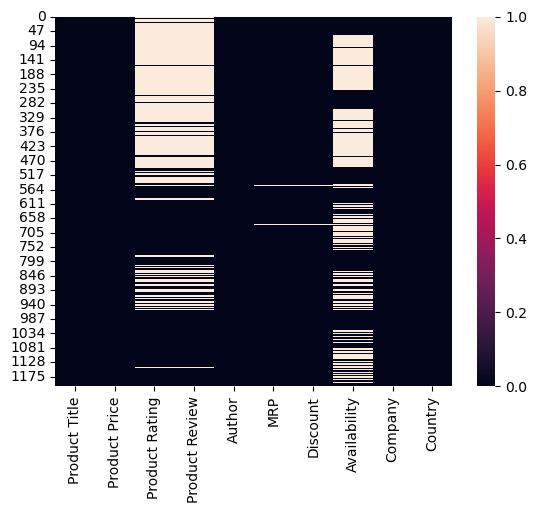

In [138]:
sns.heatmap(df.isnull())

In [142]:
df.isnull().sum()

Product Title       0
Product Price       0
Product Rating    577
Product Review    577
Author              0
MRP                 4
Discount            5
Availability      609
Company             0
Country             0
dtype: int64

In [146]:
df["Availability"].isnull().sum()

np.int64(609)

In [148]:
df["Availability"].value_counts()

Availability
Only few left                  155
Big Billion Days Price         142
Hot Deal                       124
Only 1 left                     55
Only 2 left                     36
Buy 2 items, save extra ₹20     27
Only 3 left                     24
Lowest price since launch       10
Only 4 left                      9
Only 5 left                      6
Lowest price in the year         5
Super Deals                      3
Buy 2 items, save extra ₹40      2
Name: count, dtype: int64

In [144]:
df["Company"].value_counts()

Company
DC          250
Japanese    250
Marvel      240
ACK         205
Diamond     192
Raj          70
Name: count, dtype: int64

In [145]:
df["Country"].value_counts()

Country
United States    490
India            467
Japan            250
Name: count, dtype: int64

In [150]:
df.head(10)

,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company,Country
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left,Marvel,United States
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left,Marvel,United States
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left,Marvel,United States
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left,Marvel,United States
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left,Marvel,United States
5,Avengers Epic Collection: Taking A.I.M.English...,"₹1,999",4.7,(138),"English, Paperback, Harras Bob","₹4,171",52% off,Only few left,Marvel,United States
6,Star Wars Legends: The Empire Omnibus Vol. 2En...,"₹10,550",NaN,NaN,"English, Hardcover, unknown","₹16,416",35% off,Only 2 left,Marvel,United States
7,"Marvel Black Panther Wakanda Forever!English, ...",₹299,4.7,(138),"English, Hardcover, March Julia",₹850,38% off,Only 1 left,Marvel,United States
8,"Marvel Studios Be More Spider-ManEnglish, Hard...",₹383,NaN,NaN,"English, Hardcover, Knox Kelly",₹550,30% off,Only few left,Marvel,United States
9,Daredevil Epic Collection: Going Out WestEngli...,"₹2,084",NaN,NaN,"English, Paperback, Conway Gerry","₹3,499",40% off,Only 1 left,Marvel,United States


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Title   1207 non-null   object 
 1   Product Price   1207 non-null   object 
 2   Product Rating  630 non-null    float64
 3   Product Review  630 non-null    object 
 4   Author          1207 non-null   object 
 5   MRP             1203 non-null   object 
 6   Discount        1202 non-null   object 
 7   Availability    598 non-null    object 
 8   Company         1207 non-null   object 
 9   Country         1207 non-null   object 
dtypes: float64(1), object(9)
memory usage: 94.4+ KB


In [152]:
# Step 1: Drop duplicates based on Product Title 
df = df.drop_duplicates(subset=["Product Title"], keep="first")

print("Total rows after removing duplicates:", len(df))


Total rows after removing duplicates: 966


In [153]:
df["Product Review"] = df["Product Review"].str.extract(r'(\d+)').astype(float)

C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_30172\2376887297.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Product Review"] = df["Product Review"].str.extract(r'(\d+)').astype(float)


In [215]:
import pandas as pd

file = "comic_anime.csv"
df = pd.read_csv(file)
df_raw = df.copy()   # backup original
df.head()


,Product Title,Product Price,Product Rating,Product Review,Author,MRP,Discount,Availability,Company,Country
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left,Marvel,United States
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left,Marvel,United States
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left,Marvel,United States
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left,Marvel,United States
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left,Marvel,United States


In [216]:
# normalize column names to snake_case for easier use
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_title   1207 non-null   object 
 1   product_price   1207 non-null   object 
 2   product_rating  630 non-null    float64
 3   product_review  630 non-null    object 
 4   author          1207 non-null   object 
 5   mrp             1203 non-null   object 
 6   discount        1202 non-null   object 
 7   availability    598 non-null    object 
 8   company         1207 non-null   object 
 9   country         1207 non-null   object 
dtypes: float64(1), object(9)
memory usage: 94.4+ KB


,product_title,product_price,product_rating,product_review,author,mrp,discount,availability,company,country
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left,Marvel,United States
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left,Marvel,United States
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left,Marvel,United States
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left,Marvel,United States
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left,Marvel,United States


In [217]:
for c in df.select_dtypes(include=['object']):
    df[c] = df[c].str.strip()   # .str.strip() preserves NaN
df.head()

,product_title,product_price,product_rating,product_review,author,mrp,discount,availability,company,country
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",₹899,2.3,(3),"English, Paperback, Hickman Jonathan","₹1,758",48% off,Only few left,Marvel,United States
1,"World of Reading Avengers Boxed SetEnglish, Pa...","₹1,178",NaN,NaN,"English, Paperback, DBG","₹1,316",10% off,Only few left,Marvel,United States
2,Trapped by the Green Goblin! (Marvel: Spider-M...,₹617,NaN,NaN,"English, Hardcover, Berrios Frank",₹822,24% off,Only few left,Marvel,United States
3,Marvel Avengers The Ultimate Character Guide N...,₹522,3.9,(8),"English, Hardcover, DK",₹699,25% off,Only few left,Marvel,United States
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",₹899,5.0,(3),"English, Paperback, Aaron Jason","₹1,949",53% off,Only few left,Marvel,United States


In [218]:
def money_to_numeric(series):
    return pd.to_numeric(series.str.replace(r'[^\d.]', '', regex=True), errors='coerce')

df['product_price'] = money_to_numeric(df['product_price'])
df['mrp'] = money_to_numeric(df['mrp'])

# Quick check
df[['product_price','mrp']].describe()


,product_price,mrp
count,1207.000000,1203.000000
mean,1221.791218,1961.268495
std,1651.728855,2469.272075
min,32.000000,40.000000
25%,203.000000,437.000000
50%,644.000000,1150.000000
75%,1612.000000,2399.000000
max,10930.000000,16416.000000


In [219]:
df['discount_pct'] = df['discount'].str.extract(r'(\d+)').astype(int)
# If you prefer 0 instead of NaN:
df['discount_pct'] = df['discount_pct'].fillna(0)
df['discount_pct'].value_counts(dropna=False).head()


discount_pct
20.0    75
7.0     45
34.0    40
25.0    38
28.0    37
Name: count, dtype: int64

In [220]:
df['review_count'] = df['product_review'].str.extract(r'(\d+)').astype(float)
# Optionally cast to int (after filling NaNs):
df['review_count'] = df['review_count'].fillna(0).astype(int)
df['review_count'].head()


0    3
1    0
2    0
3    8
4    3
Name: review_count, dtype: int64

In [221]:
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')
df['product_rating'].describe()
df['product_rating'].isna().sum()   # how many missing ratings?

np.int64(577)

In [222]:
df['company'] = df['company'].str.title().str.strip()
df['country'] = df['country'].str.title().str.strip()
df['product_title'] = df['product_title'].str.strip()

In [223]:
# Inspect duplicates first
dupes = df.duplicated(subset=['product_title','author','mrp'], keep=False)
df[dupes].sort_values(['product_title']).head(20)

# Remove exact duplicates keeping first occurrence
df = df.drop_duplicates(subset=['product_title','author','mrp'], keep='first')


In [224]:


df["review_count"].isnull().sum()

np.int64(0)

In [225]:
import re

def classify_availability(text):
    if not text or pd.isna(text):
        return "in_stock"
    
    t = text.lower()
    
    # out of stock
    if "out of stock" in t:
        return "out_of_stock"
    
    # low stock (patterns like "only 1 left", "only 2 left", "few left", "limited")
    if re.search(r'(only\s*\d+\s*left|few left|limited)', t):
        return "low_stock"
    
    # explicitly in stock
    if "in stock" in t:
        return "in_stock"
    
    # promotional tags
    if any(x in t for x in ["hot deal", "big billion", "offer", "deal"]):
        return "promotion"
    
    # fallback
    return "other"

df['availability_status'] = df['availability'].apply(classify_availability)

df['availability_status'].value_counts()


availability_status
in_stock     476
low_stock    255
promotion    216
other         21
Name: count, dtype: int64

In [228]:
import re

# language keywords (expand as needed)
LANGUAGES = ["english", "hindi", "marathi", "gujarati", "bengali"]

# format keywords (book types / editions)
FORMATS = ["paperback", "hardcover", "handbound", "box set", "multicolor", "multi color"]


In [229]:
def split_author_info(text):
    if pd.isna(text):
        return pd.Series([pd.NA, pd.NA, pd.NA])
    
    t = text.lower()
    parts = [p.strip() for p in re.split(r'[,\-]', t) if p.strip()]  # split by comma/hyphen
    
    language = None
    book_format = None
    writer = []
    
    for p in parts:
        if any(lang in p for lang in LANGUAGES):
            language = p
        elif any(fmt in p for fmt in FORMATS):
            book_format = p
        else:
            writer.append(p)
    
    # Join remaining words for writer (in case name has spaces/commas)
    writer = " ".join(writer).title().strip() if writer else None
    
    return pd.Series([language, writer, book_format])


In [230]:
df[['language','writer','format']] = df['author'].apply(split_author_info)
df[['author','language','writer','format']].head(20)


,author,language,writer,format
0,"English, Paperback, Hickman Jonathan",english,Hickman Jonathan,paperback
1,"English, Paperback, DBG",english,Dbg,paperback
2,"English, Hardcover, Berrios Frank",english,Berrios Frank,hardcover
3,"English, Hardcover, DK",english,Dk,hardcover
4,"English, Paperback, Aaron Jason",english,Aaron Jason,paperback
5,"English, Paperback, Harras Bob",english,Harras Bob,paperback
6,"English, Hardcover, unknown",english,Unknown,hardcover
7,"English, Hardcover, March Julia",english,March Julia,hardcover
8,"English, Hardcover, Knox Kelly",english,Knox Kelly,hardcover
9,"English, Paperback, Conway Gerry",english,Conway Gerry,paperback


In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, 0 to 1205
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_title        919 non-null    object 
 1   product_price        919 non-null    int64  
 2   product_rating       480 non-null    float64
 3   product_review       480 non-null    object 
 4   author               919 non-null    object 
 5   mrp                  915 non-null    float64
 6   discount             914 non-null    object 
 7   availability         469 non-null    object 
 8   company              919 non-null    object 
 9   country              919 non-null    object 
 10  discount_pct         919 non-null    float64
 11  review_count         919 non-null    int64  
 12  availability_status  919 non-null    object 
 13  is_junk              919 non-null    bool   
 14  language             756 non-null    object 
 15  writer               910 non-null    object 

In [232]:
df

,product_title,product_price,product_rating,product_review,author,mrp,discount,availability,company,country,discount_pct,review_count,availability_status,is_junk,language,writer,format
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",899,2.3,(3),"English, Paperback, Hickman Jonathan",1758.0,48% off,Only few left,Marvel,United States,48.0,3,low_stock,False,english,Hickman Jonathan,paperback
1,"World of Reading Avengers Boxed SetEnglish, Pa...",1178,NaN,NaN,"English, Paperback, DBG",1316.0,10% off,Only few left,Marvel,United States,10.0,0,low_stock,False,english,Dbg,paperback
2,Trapped by the Green Goblin! (Marvel: Spider-M...,617,NaN,NaN,"English, Hardcover, Berrios Frank",822.0,24% off,Only few left,Marvel,United States,24.0,0,low_stock,False,english,Berrios Frank,hardcover
3,Marvel Avengers The Ultimate Character Guide N...,522,3.9,(8),"English, Hardcover, DK",699.0,25% off,Only few left,Marvel,United States,25.0,8,low_stock,False,english,Dk,hardcover
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",899,5.0,(3),"English, Paperback, Aaron Jason",1949.0,53% off,Only few left,Marvel,United States,53.0,3,low_stock,False,english,Aaron Jason,paperback
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,"Boruto: Naruto Next Generations, Vol. 15Englis...",591,3.3,(3),"English, Paperback, Kishimoto Masashi",969.0,39% off,Hot Deal,Japanese,Japan,39.0,3,promotion,False,english,Kishimoto Masashi,paperback
1200,"Naruto, Vol. 55English, Paperback, Kishimoto M...",591,4.4,(13),"English, Paperback, Kishimoto Masashi",799.0,26% off,NaN,Japanese,Japan,26.0,13,in_stock,False,english,Kishimoto Masashi,paperback
1203,"Naruto, Vol. 13English, Paperback, Kishimoto M...",591,4.8,(4),"English, Paperback, Kishimoto Masashi",799.0,26% off,NaN,Japanese,Japan,26.0,4,in_stock,False,english,Kishimoto Masashi,paperback
1204,"Toilet-bound Hanako-kun, Vol. 12English, Paper...",866,4.4,(12),"English, Paperback, AidaIro AidaIro",1655.0,47% off,Big Billion Days Price,Japanese,Japan,47.0,12,promotion,False,english,Aidairo Aidairo,paperback


In [236]:
import pandas as pd
import re

def clean_title(title):
    pattern = r'^(?:Currently unavailable)?\s*(.+?)\s*(?:English|Hindi|Marathi|Gujarati|Bengali|Paperback|Hardcover|Handbound|Box\s*set|Multicolor|Multi\s*color)'
    match = re.match(pattern, str(title))
    return match.group(1).strip() if match else title

df['title'] = df['product_title'].apply(clean_title)


In [239]:
df

,product_title,product_price,product_rating,product_review,author,mrp,discount,availability,company,country,discount_pct,review_count,availability_status,is_junk,language,writer,format,title
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",899,2.3,(3),"English, Paperback, Hickman Jonathan",1758.0,48% off,Only few left,Marvel,United States,48.0,3,low_stock,False,english,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,"World of Reading Avengers Boxed SetEnglish, Pa...",1178,NaN,NaN,"English, Paperback, DBG",1316.0,10% off,Only few left,Marvel,United States,10.0,0,low_stock,False,english,Dbg,paperback,World of Reading Avengers Boxed Set
2,Trapped by the Green Goblin! (Marvel: Spider-M...,617,NaN,NaN,"English, Hardcover, Berrios Frank",822.0,24% off,Only few left,Marvel,United States,24.0,0,low_stock,False,english,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,Marvel Avengers The Ultimate Character Guide N...,522,3.9,(8),"English, Hardcover, DK",699.0,25% off,Only few left,Marvel,United States,25.0,8,low_stock,False,english,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",899,5.0,(3),"English, Paperback, Aaron Jason",1949.0,53% off,Only few left,Marvel,United States,53.0,3,low_stock,False,english,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,"Boruto: Naruto Next Generations, Vol. 15Englis...",591,3.3,(3),"English, Paperback, Kishimoto Masashi",969.0,39% off,Hot Deal,Japanese,Japan,39.0,3,promotion,False,english,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
1200,"Naruto, Vol. 55English, Paperback, Kishimoto M...",591,4.4,(13),"English, Paperback, Kishimoto Masashi",799.0,26% off,NaN,Japanese,Japan,26.0,13,in_stock,False,english,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
1203,"Naruto, Vol. 13English, Paperback, Kishimoto M...",591,4.8,(4),"English, Paperback, Kishimoto Masashi",799.0,26% off,NaN,Japanese,Japan,26.0,4,in_stock,False,english,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
1204,"Toilet-bound Hanako-kun, Vol. 12English, Paper...",866,4.4,(12),"English, Paperback, AidaIro AidaIro",1655.0,47% off,Big Billion Days Price,Japanese,Japan,47.0,12,promotion,False,english,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, 0 to 1205
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_title        919 non-null    object 
 1   product_price        919 non-null    int64  
 2   product_rating       480 non-null    float64
 3   product_review       480 non-null    object 
 4   author               919 non-null    object 
 5   mrp                  915 non-null    float64
 6   discount             914 non-null    object 
 7   availability         469 non-null    object 
 8   company              919 non-null    object 
 9   country              919 non-null    object 
 10  discount_pct         919 non-null    float64
 11  review_count         919 non-null    int64  
 12  availability_status  919 non-null    object 
 13  is_junk              919 non-null    bool   
 14  language             756 non-null    object 
 15  writer               910 non-null    object 

In [241]:
df.to_csv('comic_manga1.csv', index=False)

In [34]:
import pandas as pd
df = pd.read_csv('comic_manga1.csv')
df

,product_title,product_price,product_rating,product_review,author,mrp,discount,availability,company,country,discount_pct,review_count,availability_status,is_junk,language,writer,format,title
0,"X-Men: Hellfire GalaEnglish, Paperback, Hickma...",899,2.3,(3),"English, Paperback, Hickman Jonathan",1758.0,48% off,Only few left,Marvel,United States,48.0,3,low_stock,False,english,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,"World of Reading Avengers Boxed SetEnglish, Pa...",1178,NaN,NaN,"English, Paperback, DBG",1316.0,10% off,Only few left,Marvel,United States,10.0,0,low_stock,False,english,Dbg,paperback,World of Reading Avengers Boxed Set
2,Trapped by the Green Goblin! (Marvel: Spider-M...,617,NaN,NaN,"English, Hardcover, Berrios Frank",822.0,24% off,Only few left,Marvel,United States,24.0,0,low_stock,False,english,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,Marvel Avengers The Ultimate Character Guide N...,522,3.9,(8),"English, Hardcover, DK",699.0,25% off,Only few left,Marvel,United States,25.0,8,low_stock,False,english,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,"Avengers By Jason Aaron Vol. 9English, Paperba...",899,5.0,(3),"English, Paperback, Aaron Jason",1949.0,53% off,Only few left,Marvel,United States,53.0,3,low_stock,False,english,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,"Boruto: Naruto Next Generations, Vol. 15Englis...",591,3.3,(3),"English, Paperback, Kishimoto Masashi",969.0,39% off,Hot Deal,Japanese,Japan,39.0,3,promotion,False,english,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
915,"Naruto, Vol. 55English, Paperback, Kishimoto M...",591,4.4,(13),"English, Paperback, Kishimoto Masashi",799.0,26% off,NaN,Japanese,Japan,26.0,13,in_stock,False,english,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
916,"Naruto, Vol. 13English, Paperback, Kishimoto M...",591,4.8,(4),"English, Paperback, Kishimoto Masashi",799.0,26% off,NaN,Japanese,Japan,26.0,4,in_stock,False,english,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
917,"Toilet-bound Hanako-kun, Vol. 12English, Paper...",866,4.4,(12),"English, Paperback, AidaIro AidaIro",1655.0,47% off,Big Billion Days Price,Japanese,Japan,47.0,12,promotion,False,english,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_title        919 non-null    object 
 1   product_price        919 non-null    int64  
 2   product_rating       480 non-null    float64
 3   product_review       480 non-null    object 
 4   author               919 non-null    object 
 5   mrp                  915 non-null    float64
 6   discount             914 non-null    object 
 7   availability         469 non-null    object 
 8   company              919 non-null    object 
 9   country              919 non-null    object 
 10  discount_pct         919 non-null    float64
 11  review_count         919 non-null    int64  
 12  availability_status  919 non-null    object 
 13  is_junk              919 non-null    bool   
 14  language             756 non-null    object 
 15  writer               910 non-null    obj

In [36]:
df = df.drop(df.index[692:709])

In [37]:
df = df.drop(columns=['author'])

In [38]:
df = df.drop(columns=['product_review'])

In [39]:
df = df.drop(columns=['product_title'])

In [40]:
df = df.drop(columns=['discount'])

In [41]:
df["availability"].value_counts()

availability
Only few left                  143
Big Billion Days Price         101
Hot Deal                        87
Only 1 left                     51
Only 2 left                     32
Only 3 left                     16
Only 4 left                      9
Lowest price since launch        7
Buy 2 items, save extra ₹20      7
Only 5 left                      4
Lowest price in the year         3
Super Deals                      2
Buy 2 items, save extra ₹40      2
Name: count, dtype: int64

In [42]:
df = df.drop(columns=['availability'])

In [43]:
df = df.drop(columns=['is_junk'])

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 902 entries, 0 to 918
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_price        902 non-null    int64  
 1   product_rating       472 non-null    float64
 2   mrp                  898 non-null    float64
 3   company              902 non-null    object 
 4   country              902 non-null    object 
 5   discount_pct         902 non-null    float64
 6   review_count         902 non-null    int64  
 7   availability_status  902 non-null    object 
 8   language             756 non-null    object 
 9   writer               893 non-null    object 
 10  format               886 non-null    object 
 11  title                902 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 91.6+ KB


In [45]:
df

,product_price,product_rating,mrp,company,country,discount_pct,review_count,availability_status,language,writer,format,title
0,899,2.3,1758.0,Marvel,United States,48.0,3,low_stock,english,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,1178,NaN,1316.0,Marvel,United States,10.0,0,low_stock,english,Dbg,paperback,World of Reading Avengers Boxed Set
2,617,NaN,822.0,Marvel,United States,24.0,0,low_stock,english,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,522,3.9,699.0,Marvel,United States,25.0,8,low_stock,english,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,899,5.0,1949.0,Marvel,United States,53.0,3,low_stock,english,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...
914,591,3.3,969.0,Japanese,Japan,39.0,3,promotion,english,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
915,591,4.4,799.0,Japanese,Japan,26.0,13,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
916,591,4.8,799.0,Japanese,Japan,26.0,4,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
917,866,4.4,1655.0,Japanese,Japan,47.0,12,promotion,english,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


In [46]:
df['product_rating'].fillna(0, inplace=True)

C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_15552\3685032971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_rating'].fillna(0, inplace=True)


In [47]:
nan_mrp_rows = df[df['mrp'].isna()]

# Display these rows showing key columns for context
print(nan_mrp_rows[['title', 'mrp', 'product_price']])

                           title  mrp  product_price
432                      Dhikkar  NaN             50
510  Tinkle Double Digest No. 61  NaN            181
547               Sati and Shiva  NaN            100
656   Chacha Chaudhary and Witch  NaN            100


In [48]:
nan_mrp_indices = df[df['mrp'].isna()].index

# Drop these rows
df = df.drop(nan_mrp_indices)


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 898 entries, 0 to 918
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_price        898 non-null    int64  
 1   product_rating       898 non-null    float64
 2   mrp                  898 non-null    float64
 3   company              898 non-null    object 
 4   country              898 non-null    object 
 5   discount_pct         898 non-null    float64
 6   review_count         898 non-null    int64  
 7   availability_status  898 non-null    object 
 8   language             753 non-null    object 
 9   writer               889 non-null    object 
 10  format               882 non-null    object 
 11  title                898 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 91.2+ KB


In [50]:
mean_rating_by_language = df.groupby('language')['product_rating'].mean()
print(mean_rating_by_language)


language
bengali             3.870000
english             2.033032
gujarati            1.900000
hindi               2.477966
marathi             2.760000
thindiath rajani    4.542857
thindiath rajni     4.250000
Name: product_rating, dtype: float64


In [51]:
format_mode = df['format'].mode()
print("Mode of format column:", format_mode.values)

Mode of format column: ['paperback']


In [52]:
language_mode = df['language'].mode()
print("Mode of language column:", language_mode.values)

Mode of language column: ['english']


In [55]:
df.to_csv('comic_manga2.csv', index=False)

In [56]:
df = pd.read_csv('comic_manga2.csv')
df

,product_price,product_rating,mrp,company,country,discount_pct,review_count,availability_status,language,writer,format,title
0,899,2.3,1758.0,Marvel,United States,48.0,3,low_stock,english,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,1178,0.0,1316.0,Marvel,United States,10.0,0,low_stock,english,Dbg,paperback,World of Reading Avengers Boxed Set
2,617,0.0,822.0,Marvel,United States,24.0,0,low_stock,english,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,522,3.9,699.0,Marvel,United States,25.0,8,low_stock,english,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,899,5.0,1949.0,Marvel,United States,53.0,3,low_stock,english,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...
893,591,3.3,969.0,Japanese,Japan,39.0,3,promotion,english,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
894,591,4.4,799.0,Japanese,Japan,26.0,13,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
895,591,4.8,799.0,Japanese,Japan,26.0,4,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
896,866,4.4,1655.0,Japanese,Japan,47.0,12,promotion,english,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


In [57]:
missing_language_by_country = df.groupby('country')['language'].apply(lambda x: x.isna().sum())

print(missing_language_by_country)

country
India            89
Japan            52
United States     4
Name: language, dtype: int64


In [58]:
def fill_language(row):
    if pd.isna(row['language']):
        if row['country'] == 'India':
            return 'Hindi'
        elif row['country'] in ['Japan', 'United States']:
            return 'English'
    return row['language']

# Apply the function row-wise
df['language'] = df.apply(fill_language, axis=1)

In [62]:
df["format"].value_counts()

format
paperback    662
hardcover    219
box sets       1
Name: count, dtype: int64

In [63]:
format_mode = df['format'].mode()[0]
print('Mode of format column:', format_mode)


Mode of format column: paperback


In [64]:
df['format'].fillna('paperback', inplace=True)

C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_15552\4086527302.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['format'].fillna('paperback', inplace=True)


In [65]:
df['writer'].fillna('Unknown', inplace=True)

C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_15552\4233273652.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['writer'].fillna('Unknown', inplace=True)


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_price        898 non-null    int64  
 1   product_rating       898 non-null    float64
 2   mrp                  898 non-null    float64
 3   company              898 non-null    object 
 4   country              898 non-null    object 
 5   discount_pct         898 non-null    float64
 6   review_count         898 non-null    int64  
 7   availability_status  898 non-null    object 
 8   language             898 non-null    object 
 9   writer               898 non-null    object 
 10  format               898 non-null    object 
 11  title                898 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 84.3+ KB


In [68]:
df

,product_price,product_rating,mrp,company,country,discount_pct,review_count,availability_status,language,writer,format,title
0,899,2.3,1758.0,Marvel,United States,48.0,3,low_stock,english,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,1178,0.0,1316.0,Marvel,United States,10.0,0,low_stock,english,Dbg,paperback,World of Reading Avengers Boxed Set
2,617,0.0,822.0,Marvel,United States,24.0,0,low_stock,english,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,522,3.9,699.0,Marvel,United States,25.0,8,low_stock,english,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,899,5.0,1949.0,Marvel,United States,53.0,3,low_stock,english,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...
893,591,3.3,969.0,Japanese,Japan,39.0,3,promotion,english,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
894,591,4.4,799.0,Japanese,Japan,26.0,13,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
895,591,4.8,799.0,Japanese,Japan,26.0,4,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
896,866,4.4,1655.0,Japanese,Japan,47.0,12,promotion,english,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


In [69]:
df["language"].value_counts()

language
english             663
Hindi                89
hindi                59
English              56
bengali              10
thindiath rajani      7
gujarati              7
marathi               5
thindiath rajni       2
Name: count, dtype: int64

In [72]:
df = df[~df['language'].isin(['thindiath rajni', ' thindiath rajani'])]

In [73]:
df["language"].value_counts()

language
english     663
Hindi        89
hindi        59
English      56
bengali      10
gujarati      7
marathi       5
Name: count, dtype: int64

In [75]:
df

,product_price,product_rating,mrp,company,country,discount_pct,review_count,availability_status,language,writer,format,title
0,899,2.3,1758.0,Marvel,United States,48.0,3,low_stock,english,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,1178,0.0,1316.0,Marvel,United States,10.0,0,low_stock,english,Dbg,paperback,World of Reading Avengers Boxed Set
2,617,0.0,822.0,Marvel,United States,24.0,0,low_stock,english,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,522,3.9,699.0,Marvel,United States,25.0,8,low_stock,english,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,899,5.0,1949.0,Marvel,United States,53.0,3,low_stock,english,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...
893,591,3.3,969.0,Japanese,Japan,39.0,3,promotion,english,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
894,591,4.4,799.0,Japanese,Japan,26.0,13,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
895,591,4.8,799.0,Japanese,Japan,26.0,4,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
896,866,4.4,1655.0,Japanese,Japan,47.0,12,promotion,english,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


In [76]:
import pandas as pd
import re

def clean_title(title):
    pattern = r'^(?:Currently unavailable)?\s*(.+?)\s*(?:English|Hindi|Marathi|Gujarati|Bengali|Paperback|Hardcover|Handbound|Box\s*set|Multicolor|Multi\s*color|Solid|Hin..|\à|\?)'
    match = re.match(pattern, str(title))
    return match.group(1).strip() if match else title

df['comic title'] = df['title'].apply(clean_title)


In [79]:
df.drop(columns=['title'], inplace=True)
df

,product_price,product_rating,mrp,company,country,discount_pct,review_count,availability_status,language,writer,format,comic title
0,899,2.3,1758.0,Marvel,United States,48.0,3,low_stock,english,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,1178,0.0,1316.0,Marvel,United States,10.0,0,low_stock,english,Dbg,paperback,World of Reading Avengers Boxed Set
2,617,0.0,822.0,Marvel,United States,24.0,0,low_stock,english,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,522,3.9,699.0,Marvel,United States,25.0,8,low_stock,english,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,899,5.0,1949.0,Marvel,United States,53.0,3,low_stock,english,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...
893,591,3.3,969.0,Japanese,Japan,39.0,3,promotion,english,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
894,591,4.4,799.0,Japanese,Japan,26.0,13,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
895,591,4.8,799.0,Japanese,Japan,26.0,4,in_stock,english,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
896,866,4.4,1655.0,Japanese,Japan,47.0,12,promotion,english,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


In [81]:
df.to_csv('Comicbook.csv', index=False)

In [6]:
import pandas as pd
df = pd.read_csv('Comicbook.csv')

In [5]:
print(df["language"].unique())

['english' 'English' 'hindi' 'Hindi' 'bengali' 'marathi' 'gujarati']


In [7]:
df["language"] = df["language"].str.strip().str.title()

In [8]:
print(df["language"].unique())

['English' 'Hindi' 'Bengali' 'Marathi' 'Gujarati']


In [9]:
df.to_csv('Comicbooks.csv', index=False)